# Numerische Integration


## Übungsblatt


In [1]:
import numpy as np
import matplotlib.pyplot as plt


def trapz(func, a, b, n):
    h = (b - a) / n
    x = np.linspace(a, b, n + 1)
    y = func(x)
    return (h / 2) * (y[0] + 2 * np.sum(y[1:-1]) + y[-1])


def trapz_data(x, y):
    return np.sum((x[1:] - x[:-1]) * (y[1:] + y[:-1])) / 2

### Aufgabe 1


Die Funktion

$$
    f(x) = \cos\left( 2 \pi \left(x + x^2\right) \right)
$$

deren Ableitung in der Einarbeitung zum Thema "Ableitung" bereits numerisch berechnet wurde, soll nun integriert werden:

$$
    S = \int_{-1}^1 f(x) \,dx
$$

1. Berechne $S$ mit [Wolfram|Alpha](https://www.wolframalpha.com).
2. Berechne $S$ mit der passenden Funktion aus [`scipy.integrate`](https://docs.scipy.org/doc/scipy/reference/integrate.html).
3. Berechne $S$ mit der passenden Variante der oben implementierten Trapezregel (`trapz()` oder `trapz_data()`) für unterschiedliche Anzahl Intervalle $n$. Bestimme $n$, so dass der absolute Fehler verglichen mit dem Resultat von [`scipy.integrate`](https://docs.scipy.org/doc/scipy/reference/integrate.html) kleiner als $10^{-10}$ ist.


In [2]:
# 1. Wolfram|Alpha

# https://www.wolframalpha.com/input?i=int+cos%282pi%28x%2Bx%5E2%29%29+from+-1+to+1
s1 = 0.467286

In [3]:
# 2. SciPy
from scipy.integrate import quad


def f(x):
    return np.cos(2 * np.pi * (x + x**2))


s2, s2_error = quad(f, -1, 1)
s2, s2_error

(0.46728607317886517, 6.878545121594632e-13)

In [4]:
# 3. Trapezregel

s3 = trapz(f, -1, 1, 100)
s3

np.float64(0.467286285590903)

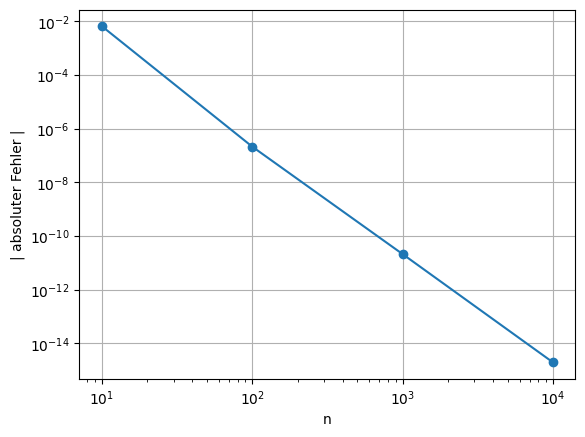

In [5]:
# Darstellung
ns = np.logspace(1, 4, 4, dtype=int)
s3s = np.array([trapz(f, -1, 1, n) for n in ns])
s3_errors = np.abs(s3s - s2)

plt.loglog(ns, s3_errors, "o-")
plt.xlabel("n")
plt.ylabel("| absoluter Fehler |")
plt.grid()
plt.show()

Also muss $n\approx 10^{3}$ gewählt werden.


### Aufgabe 2: Wasserverbrauch


#### a) Daten einlesen, darstellen, verstehen


1. Lies die Daten in `wasserverbrauch.csv` ein.
2. Stelle den Wasserverbrauch in Abhängigkeit der Zeit dar.
3. Schreibe die Achsen mit den korrekten Variablen und deren Einheiten an.
4. Bestimme die Einheit des Integrals über den Wasserverbrauch. Also was ist die Bedeutung der Fläche unter dieser Kurve?


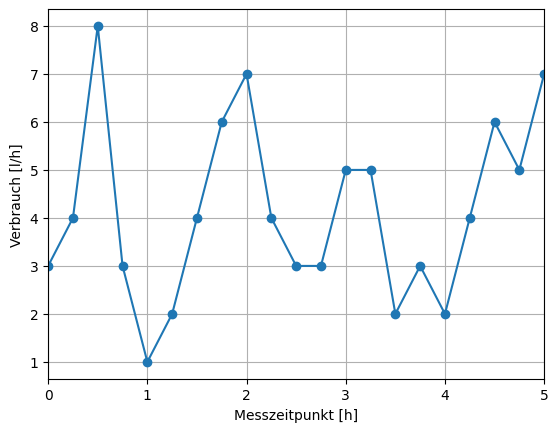

In [6]:
wasserverbrauch = np.loadtxt("wasserverbrauch.csv", delimiter=";", skiprows=1)
zeit, verbrauch = wasserverbrauch.T

plt.plot(zeit, verbrauch, "o-")
plt.xlim(zeit.min(), zeit.max())
plt.xlabel("Messzeitpunkt [h]")
plt.ylabel("Verbrauch [l/h]")
plt.grid()
plt.show()

Das Integral über den Verbrauch (in l/h) ist die Wassermenge in Litern, die im integrierten Zeitraum verbraucht wurde.


#### b) Daten integrieren


Bestimme den Wasserverbrauch von $t=1$ bis und mit $t=4$.

Benutze dazu einmal die passende Trapezregel-Funktion (zuoberst bereits definiert) und einmal [`scipy.integrate`](https://docs.scipy.org/doc/scipy/tutorial/integrate.html).


In [7]:
a, b = 1, 4
bereich = (a <= zeit) & (zeit <= b)


trapz_data(zeit[bereich], verbrauch[bereich])

np.float64(11.375)

In [8]:
from scipy.integrate import trapezoid

trapezoid(verbrauch[bereich], zeit[bereich])

np.float64(11.375)

#### c) Integrierten Bereich darstellen


Stelle die Fläche unter dem Graphen zwischen $t=1$ und $t=4$ mithilfe von [`plt.fill_between`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.fill_between.html) dar.


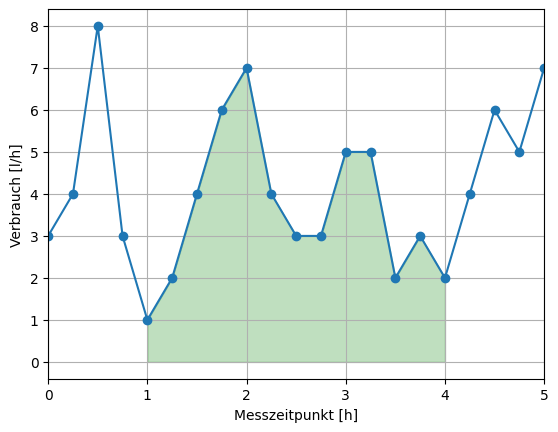

In [9]:
plt.plot(zeit, verbrauch, "o-")
plt.fill_between(zeit[bereich], verbrauch[bereich], alpha=0.25, color="green")
plt.xlim(zeit.min(), zeit.max())
plt.xlabel("Messzeitpunkt [h]")
plt.ylabel("Verbrauch [l/h]")
plt.grid()
plt.show()

### Aufgabe 3: Jogging-Rekonstruktion


Wir benutzen nochmals die Jogging-Daten, die im Übungsblatt zum Thema Ableitung bereits verwendet wurden. Hier stellen wir die Frage, ob die zurückgelegte Distanz aus der Geschwindigkeit rekonstruiert werden kann.

Die Geschwindigkeit $v(t)$ ist die Ableitung der zurückgelegten Distanz $x(t)$, also $x'(t)=v(t)$. Somit ist die zurückgelegte Distanz $x(t)$ das Integral der Geschwindigkeit $v(t)$ über die Zeit:

$$ x(t) = \int_0^t v(t') \, dt' $$

Schritte:

1. Lies die ersten drei Spalten aus der Datei `jogging.csv` ein:

    - Zeit (in Sekunden)
    - Distanz (in Metern)
    - Pace (in Minuten pro Meile)

2. Filtere die ersten paar Datenpunkte heraus, wo die Pace = 0 ist.

3. Rechne die Pace in die Geschwindigkleit in Metern pro Sekunde um (1 Meile = 1609.44 Meter).

4. Integriere die Geschwindigkeit über die Zeit, um die zurückgelegte Distanz zu bestimmen.

5. Vergleiche das Resultat mit der Distanz, die ganz am Schluss gemessen wurde.

Da die Geschwindigkeit und die Distanz von der GPS-Uhr gemessen wurden, sind die Daten nicht perfekt. Daher wird die Distanz, die am Schluss gemessen wurde, nicht ganz mit der Distanz aus der aufintegrierten Geschwindigkeit übereinstimmen.


In [10]:
# 1.-3. Import, Bereinigung & Umrechnung
jogging = np.loadtxt("jogging.csv", delimiter=";", skiprows=1, usecols=(0, 1, 2))
time, distance, pace = jogging.T

idx = np.isfinite(pace) & (pace > 0)

t_data = time[idx]
x_data = distance[idx]
v_data = 1 / pace[idx] * 1609.344 / 60

In [11]:
dist_from_v = trapz_data(t_data, v_data)

In [12]:
print("rekonstruierte Distanz:\t", dist_from_v)
print("gemessene Distanz:\t", x_data[-1])
print("absoluter Unterschied:\t", dist_from_v - x_data[-1])
print("relativer Unterschied:\t", dist_from_v / x_data[-1] - 1)

rekonstruierte Distanz:	 6860.088525670482
gemessene Distanz:	 5544.60009765625
absoluter Unterschied:	 1315.4884280142323
relativer Unterschied:	 0.23725578127271985


### Aufgabe 4: Temperaturen in Davos


Hier werden wir Daten zuerst interpolieren, um die Nullstellen bestimmen zu können. Dann wird zwischen den Nullstellen integriert.


#### a) Daten einlesen, darstellen, verstehen

-   Lies die Daten in `temperatur_weihnachten.csv` ein. Diese enthalten den Temperaturverlauf vom 24. und 25. Dezember in Davos.
-   Stelle die Temperatur in Abhängigkeit der Zeit dar mit den korrekten Achsenbeschriftungen inklusive Einheiten.


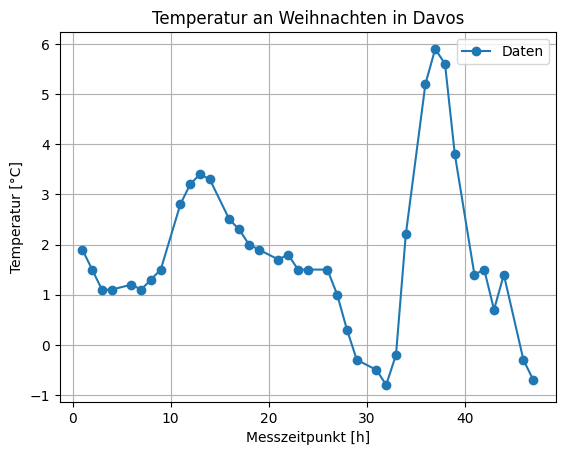

In [13]:
davos = np.loadtxt("temperatur_weihnachten.csv", delimiter=",", skiprows=1)
t_data, temp_data = davos.T

plt.plot(t_data, temp_data, "o-", label="Daten")
plt.xlabel("Messzeitpunkt [h]")
plt.ylabel("Temperatur [°C]")
plt.grid()
plt.legend()
plt.title("Temperatur an Weihnachten in Davos")
plt.show()

#### b) Interpolation

-   Konststruiere eine kubische Spline-Interpolation der Temperatur mit natürlichen Randbedingungen.
-   Stelle die Interpolationsfunktion mittels 500 Punkten im Gleichen Zeitraum wie die Daten zusammen mit den Daten grafisch dar.


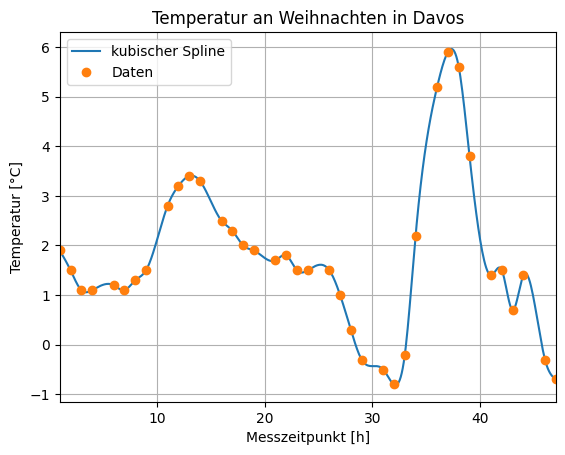

In [14]:
from scipy.interpolate import make_interp_spline

temp_spline = make_interp_spline(t_data, temp_data, bc_type="natural")


t = np.linspace(t_data.min(), t_data.max(), 500)
temp = temp_spline(t)


plt.plot(t, temp, label="kubischer Spline")
plt.plot(t_data, temp_data, "o", label="Daten")
plt.xlim(t_data.min(), t_data.max())
plt.xlabel("Messzeitpunkt [h]")
plt.ylabel("Temperatur [°C]")
plt.legend()
plt.grid()
plt.title("Temperatur an Weihnachten in Davos")
plt.show()

#### c) Nullstellen bestimmen


Im Diagramm von b) ist ersichtlich, dass die Temperatur an 3 Stellen durch 0 geht.

-   Finde alle drei Nullstellen.
-   Stelle sie im Diagramm als rote Punkte dar.

Tipp: Folgende Funktionen kannst du für diese Aufgabe benutzen:

-   [`scipy.optimize.newton`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.newton.html)
-   [`scipy.optimize.bisect`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.bisect.html)
-   [`scipy.optimize.root_scalar`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.root_scalar.html)


In [15]:
# Variante mit Newton
from scipy.optimize import newton

low = 25
high = t.max()
n = 1000

roots = np.unique(
    [
        newton(
            temp_spline,
            x0=x0,
            fprime=temp_spline.derivative(),
            fprime2=temp_spline.derivative().derivative(),
        )
        for x0 in np.linspace(25, t.max(), 1000)
    ]
)
roots

RuntimeError: Failed to converge after 50 iterations, value is 28.430820615192008.

In [ ]:
# Variante mit Bisektionsverfahren
from scipy.optimize import bisect
from itertools import pairwise

low = 25
high = t.max()
n = 1000

roots = np.unique(
    [
        bisect(temp_spline, a, b)
        for a, b in pairwise(np.linspace(low, high, n))
        if temp_spline(a) * temp_spline(b) < 0
    ]
)
roots

In [ ]:
plt.plot(t, temp, label="kubischer Spline")
plt.plot(roots, np.zeros_like(roots), "or", label="Nullstellen")
plt.xlim(t.min(), t.max())
plt.xlabel("Messzeitpunkt [h]")
plt.ylabel("Temperatur [°C]")
plt.title("Interpolierte Temperaturen mit Nullstellen")
plt.legend()
plt.grid()
plt.show()

#### d) Mittlere Temperatur bestimmen


Berechnen wir die durchschnittliche Temperatur zwischen der 1. und 3. Nullstelle.

Der Mittelwert einer Funktion $f(x)$ zwischen $a$ und $b$ ist definiert als

$$ \frac{1}{b-a} \int_a^b f(x) \, dx $$

-   Schreibe eine Funktion `mean_func(func, a, b)`, welche die den Mittelwert einer Funktion `func` zwischen zwei werten `a` und `b` mithilfe von SciPy berechnet.
-   Benutze diese, um die mittlere Temperatur zwischen der 1. und 3. Nullstelle zu berechnen.


In [ ]:
from scipy.integrate import quad


def mean_func(func, a, b):
    integral, _ = quad(func, a, b)
    return integral / (b - a)


r1, r3 = roots[0], roots[-1]

mean_temp = mean_func(temp_spline, r1, r3)
mean_temp

#### e) Darstellung


-   Stelle das Integral in dem Diagramm aus der Aufgabe c) mithilfe von [`plt.fill_between`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.fill_between.html) dar.
-   Plotte dazu den Mittelwert zwischen der 1. und 3. Nullstelle als konstante Funktion.


In [ ]:
ind = (r1 <= t) & (t <= r3)

plt.plot(t, temp, label="Temperaturverlauf")
plt.fill_between(t[ind], temp[ind], alpha=0.3)
plt.plot(
    roots, np.full_like(roots, mean_temp), "m", label=f"Mittelwert: {mean_temp:.2f}°C"
)
plt.fill_between(roots, np.full_like(roots, mean_temp), color="m", alpha=0.2)
plt.plot(roots, np.zeros_like(roots), "or", label="Nullstellen")
plt.xlim(t.min(), t.max())
plt.xlabel("Messzeitpunkt [h]")
plt.ylabel("Temperatur [°C]")
plt.title("Interpolierte Temperaturen mit Nullstellen und Mittelwert")
plt.legend()
plt.grid()
plt.show()